# XGBoost pathogenicity model (holdout)

Gene-grouped train/valid/test via `src/holdout_train_eval.py`, then XGBoost fit/eval.
Target: `label` (pathogenic vs benign). Genes never appear in more than one split.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)


In [2]:
load_dotenv()
project_root = Path(os.environ["PROJECT_ROOT"])
sys.path.insert(0, str(project_root / "src"))

from holdout_train_eval import (
    FEATURE_COLUMNS,
    GROUP_COLUMN,
    align_categories_to_train,
    build_feature_matrix,
    evaluate_predictions,
    fit_predict,
    run_split,
    split_summary,
    train_holdout_model,
)

MODELS_DIR = project_root / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print("features:", FEATURE_COLUMNS)


features: ['protein_position', 'relative_protein_position', 'distance_to_closest_feature', 'has_protein_position', 'in_domain', 'in_region', 'in_zinc_finger', 'in_active_site', 'in_binding_site', 'in_disulfide', 'in_mod_res', 'in_functional_site', 'in_any_feature', 'closest_feature_type', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']


## Train / valid / test split

Calls `run_split()` from `src/holdout_train_eval.py` (same as `python src/holdout_train_eval.py`).


In [3]:
frames = run_split()
train_df, valid_df, test_df = frames["train"], frames["valid"], frames["test"]
combined = pd.concat([train_df, valid_df, test_df], ignore_index=True)
split_summary(combined)


,split,n_variants,n_genes,pct_pathogenic,pct_with_protein_position
0,train,8094,52,52.792192,75.475661
1,valid,1735,43,58.789625,81.959654
2,test,1734,42,61.072664,85.755479


In [4]:
train_genes = set(train_df[GROUP_COLUMN])
valid_genes = set(valid_df[GROUP_COLUMN])
test_genes = set(test_df[GROUP_COLUMN])
assert train_genes.isdisjoint(valid_genes)
assert train_genes.isdisjoint(test_genes)
assert valid_genes.isdisjoint(test_genes)
print("gene overlap across splits: none")


gene overlap across splits: none


## Fit and evaluate

`train_holdout_model()` builds matrices (train-only categories), fits XGBoost with
early stopping on valid, and returns metrics / importances.


In [5]:
result = train_holdout_model(frames)
model = result["model"]
metrics_table = result["metrics"]
importance = result["importance"]
proba_train = result["proba"]["train"]
proba_valid = result["proba"]["valid"]
proba_test = result["proba"]["test"]
y_train = result["matrices"]["y_train"]
y_valid = result["matrices"]["y_valid"]
y_test = result["matrices"]["y_test"]

print(
    f"best_iteration={model.best_iteration}, "
    f"best_score={model.best_score:.4f}"
)
metrics_table.round(3)



=== train ===
ROC-AUC=0.784  PR-AUC=0.795  accuracy@0.5=0.586
              precision    recall  f1-score   support

      benign      0.870     0.145     0.249      3821
  pathogenic      0.562     0.981     0.714      4273

    accuracy                          0.586      8094
   macro avg      0.716     0.563     0.481      8094
weighted avg      0.707     0.586     0.494      8094


=== valid ===
ROC-AUC=0.594  PR-AUC=0.647  accuracy@0.5=0.594
              precision    recall  f1-score   support

      benign      0.617     0.041     0.076       715
  pathogenic      0.594     0.982     0.740      1020

    accuracy                          0.594      1735
   macro avg      0.605     0.511     0.408      1735
weighted avg      0.603     0.594     0.466      1735


=== test ===
ROC-AUC=0.609  PR-AUC=0.678  accuracy@0.5=0.618
              precision    recall  f1-score   support

      benign      0.676     0.037     0.070       675
  pathogenic      0.617     0.989     0.760      

,n,roc_auc,pr_auc,accuracy
split,,,,
train,8094,0.784,0.795,0.586
valid,1735,0.594,0.647,0.594
test,1734,0.609,0.678,0.618


## Curves and confusion matrix


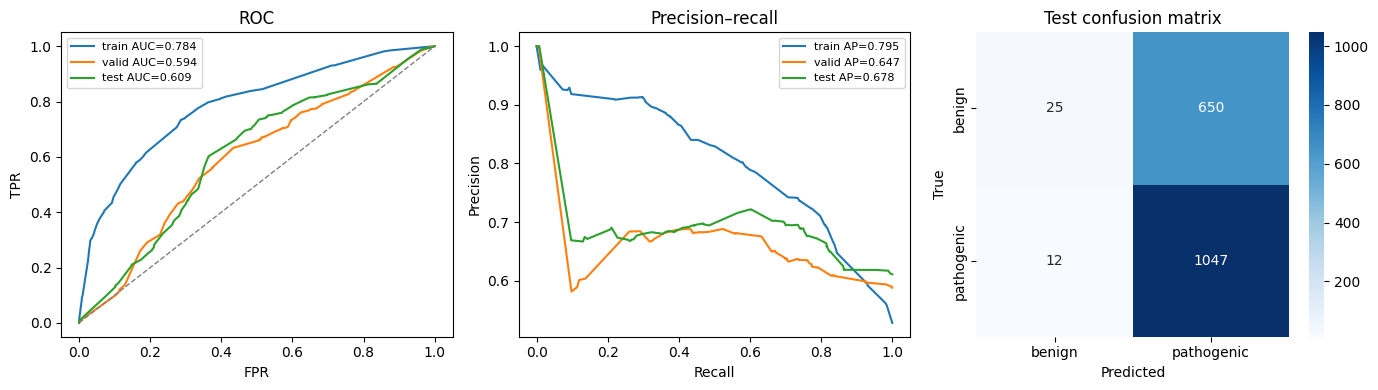

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for name, y_true, proba in [
    ("train", y_train, proba_train),
    ("valid", y_valid, proba_valid),
    ("test", y_test, proba_test),
]:
    fpr, tpr, _ = roc_curve(y_true, proba)
    axes[0].plot(fpr, tpr, label=f"{name} AUC={roc_auc_score(y_true, proba):.3f}")
    prec, rec, _ = precision_recall_curve(y_true, proba)
    axes[1].plot(rec, prec, label=f"{name} AP={average_precision_score(y_true, proba):.3f}")

axes[0].plot([0, 1], [0, 1], ls="--", c="gray", lw=1)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("ROC")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–recall")
axes[1].legend(fontsize=8)

cm = confusion_matrix(y_test, (proba_test >= 0.5).astype(int))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["benign", "pathogenic"],
    yticklabels=["benign", "pathogenic"],
    ax=axes[2],
)
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")
axes[2].set_title("Test confusion matrix")

fig.tight_layout()
plt.show()

## Feature importance

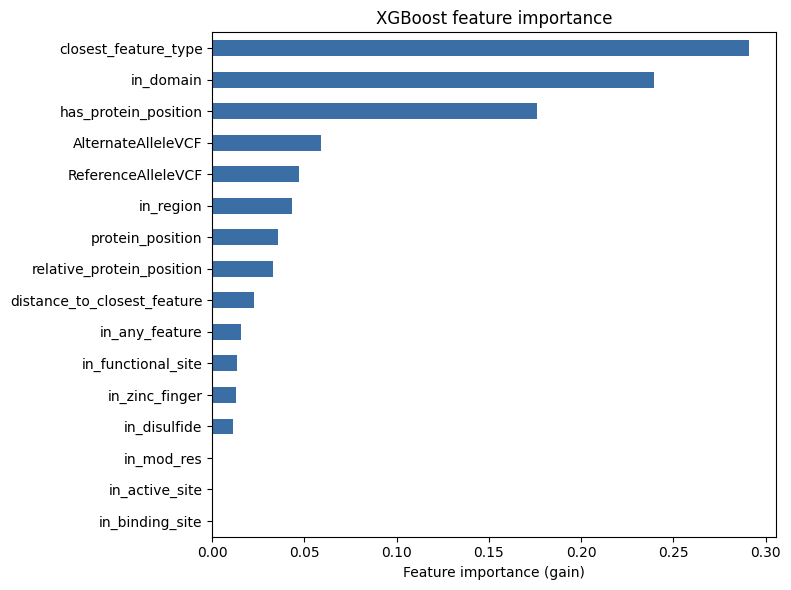

,gain
closest_feature_type,0.290864
in_domain,0.239613
has_protein_position,0.176007
AlternateAlleleVCF,0.058785
ReferenceAlleleVCF,0.046863
in_region,0.043098
protein_position,0.035632
relative_protein_position,0.033211
distance_to_closest_feature,0.022736
in_any_feature,0.015469


In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
importance.sort_values().plot.barh(ax=ax, color="#3b6ea5")
ax.set_xlabel("Feature importance (gain)")
ax.set_title("XGBoost feature importance")
fig.tight_layout()
plt.show()

importance.to_frame()


## Persist model

In [8]:
model_path = MODELS_DIR / "xgb_pathogenicity.json"
model.save_model(model_path)
print("Saved", model_path)
metrics_table.round(3)

Saved /home/milijanas/projects/clinvar-pathogenicity-classifier/models/xgb_pathogenicity.json


,n,roc_auc,pr_auc,accuracy
split,,,,
train,8094,0.784,0.795,0.586
valid,1735,0.594,0.647,0.594
test,1734,0.609,0.678,0.618
